# 4. Evaluation - Retrieval Metrics & RAGAS

This notebook evaluates the RAG pipeline from two complementary perspectives:

1. **Retrieval Metrics (No LLM Required):** Hit Rate, Precision, Recall at various k, and MRR -- comparing before vs. after reranking.
2. **LLM-Based RAGAS Metrics:** Faithfulness and Factual Correctness, evaluated using Claude via the LangChain wrapper.

Input: `results/rag_results.jsonl` produced by Notebook 3.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

In [2]:
load_dotenv(Path("..") / ".env")

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "results"

# Load results
results = []
with open(RESULTS_DIR / "rag_results.jsonl", "r") as f:
    for line in f:
        results.append(json.loads(line))

print(f"Loaded {len(results)} results")

Loaded 500 results


## 4.1 Retrieval Metrics (No LLM Required)

These metrics compare retrieved document IDs against golden_doc IDs. We compute them for both the initial retrieval (before rerank) and after reranking to quantify the reranker's impact.

In [3]:
def hit_rate_at_k(retrieved_docs, golden_docs, k):
    """1 if any golden doc is in top-k retrieved, else 0."""
    if not golden_docs:
        return None  # Skip queries with no golden docs
    top_k = retrieved_docs[:k]
    return 1.0 if any(g in top_k for g in golden_docs) else 0.0

def mrr(retrieved_docs, golden_docs):
    """Mean Reciprocal Rank: 1/rank of first golden doc found."""
    if not golden_docs:
        return None
    for i, doc in enumerate(retrieved_docs):
        if doc in golden_docs:
            return 1.0 / (i + 1)
    return 0.0

def precision_at_k(retrieved_docs, golden_docs, k):
    """Fraction of top-k that are golden docs."""
    if not golden_docs:
        return None
    top_k = retrieved_docs[:k]
    relevant = sum(1 for d in top_k if d in golden_docs)
    return relevant / k

def recall_at_k(retrieved_docs, golden_docs, k):
    """Fraction of golden docs found in top-k."""
    if not golden_docs:
        return None
    top_k = retrieved_docs[:k]
    found = sum(1 for g in golden_docs if g in top_k)
    return found / len(golden_docs)

In [4]:
k_values = [1, 3, 5, 10, 20]

metrics_before = {f"hit_rate@{k}": [] for k in k_values}
metrics_before.update({f"precision@{k}": [] for k in k_values})
metrics_before.update({f"recall@{k}": [] for k in k_values})
metrics_before["mrr"] = []

metrics_after = {f"hit_rate@{k}": [] for k in k_values}
metrics_after.update({f"precision@{k}": [] for k in k_values})
metrics_after.update({f"recall@{k}": [] for k in k_values})
metrics_after["mrr"] = []

for r in results:
    golden = r["golden_doc"]
    if not golden:
        continue
        
    docs_before = r["docs_before_rerank"]
    docs_after = r["docs_after_rerank"]
    
    for k in k_values:
        metrics_before[f"hit_rate@{k}"].append(hit_rate_at_k(docs_before, golden, k))
        metrics_before[f"precision@{k}"].append(precision_at_k(docs_before, golden, k))
        metrics_before[f"recall@{k}"].append(recall_at_k(docs_before, golden, k))
        
        metrics_after[f"hit_rate@{k}"].append(hit_rate_at_k(docs_after, golden, k))
        metrics_after[f"precision@{k}"].append(precision_at_k(docs_after, golden, k))
        metrics_after[f"recall@{k}"].append(recall_at_k(docs_after, golden, k))
    
    metrics_before["mrr"].append(mrr(docs_before, golden))
    metrics_after["mrr"].append(mrr(docs_after, golden))

# Compute means
avg_before = {k: np.mean(v) for k, v in metrics_before.items() if v}
avg_after = {k: np.mean(v) for k, v in metrics_after.items() if v}

queries_evaluated = len(metrics_before["mrr"])
print(f"Evaluated {queries_evaluated} queries (with golden docs)\n")

print("=" * 60)
print(f"{'Metric':<20} {'Before Rerank':>15} {'After Rerank':>15}")
print("=" * 60)
for metric in sorted(avg_before.keys()):
    before_val = avg_before.get(metric, 0)
    after_val = avg_after.get(metric, 0)
    print(f"{metric:<20} {before_val:>15.4f} {after_val:>15.4f}")

Evaluated 488 queries (with golden docs)

Metric                 Before Rerank    After Rerank
hit_rate@1                    0.7643          0.6906
hit_rate@10                   0.9037          0.8094
hit_rate@20                   0.9037          0.8094
hit_rate@3                    0.8320          0.7725
hit_rate@5                    0.8648          0.8094
mrr                           0.8060          0.7346
precision@1                   0.7643          0.6906
precision@10                  0.1408          0.1160
precision@20                  0.0704          0.0580
precision@3                   0.3975          0.3531
precision@5                   0.2574          0.2320
recall@1                      0.4773          0.4175
recall@10                     0.8075          0.6581
recall@20                     0.8075          0.6581
recall@3                      0.6802          0.6014
recall@5                      0.7341          0.6581


In [5]:
rows = []
for metric in sorted(avg_before.keys()):
    rows.append({
        "metric": metric,
        "before_rerank": avg_before.get(metric, 0),
        "after_rerank": avg_after.get(metric, 0),
    })

df_retrieval = pd.DataFrame(rows)
df_retrieval.to_csv(RESULTS_DIR / "retrieval_metrics.csv", index=False)
print("Saved retrieval metrics to results/retrieval_metrics.csv")
df_retrieval

Saved retrieval metrics to results/retrieval_metrics.csv


,metric,before_rerank,after_rerank
0,hit_rate@1,0.764344,0.690574
1,hit_rate@10,0.903689,0.809426
2,hit_rate@20,0.903689,0.809426
3,hit_rate@3,0.831967,0.772541
4,hit_rate@5,0.864754,0.809426
5,mrr,0.806050,0.734631
6,precision@1,0.764344,0.690574
7,precision@10,0.140779,0.115984
8,precision@20,0.070389,0.057992
9,precision@3,0.397541,0.353142


## 4.2 Retrieval Metrics Visualization

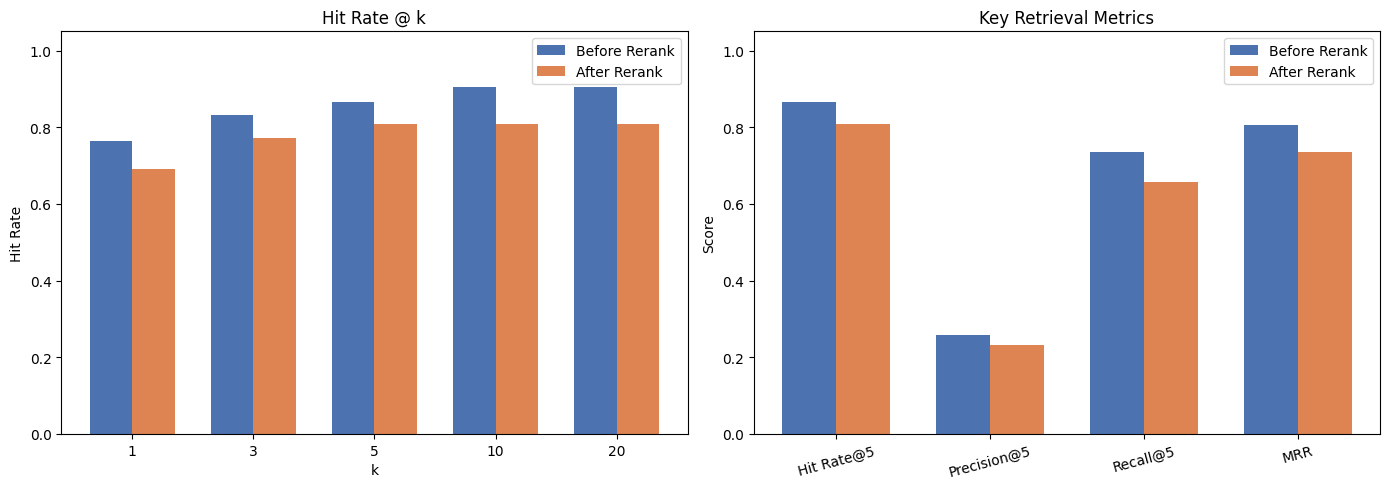

Saved figure to results/retrieval_metrics.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Hit Rate at different k
hit_before = [avg_before.get(f"hit_rate@{k}", 0) for k in k_values]
hit_after = [avg_after.get(f"hit_rate@{k}", 0) for k in k_values]

x = np.arange(len(k_values))
width = 0.35

axes[0].bar(x - width/2, hit_before, width, label="Before Rerank", color="#4C72B0")
axes[0].bar(x + width/2, hit_after, width, label="After Rerank", color="#DD8452")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Hit Rate")
axes[0].set_title("Hit Rate @ k")
axes[0].set_xticks(x)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Plot 2: Key metrics comparison (at k=5)
key_metrics = ["hit_rate@5", "precision@5", "recall@5", "mrr"]
labels = ["Hit Rate@5", "Precision@5", "Recall@5", "MRR"]
before_vals = [avg_before.get(m, 0) for m in key_metrics]
after_vals = [avg_after.get(m, 0) for m in key_metrics]

x2 = np.arange(len(key_metrics))
axes[1].bar(x2 - width/2, before_vals, width, label="Before Rerank", color="#4C72B0")
axes[1].bar(x2 + width/2, after_vals, width, label="After Rerank", color="#DD8452")
axes[1].set_ylabel("Score")
axes[1].set_title("Key Retrieval Metrics")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "retrieval_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to results/retrieval_metrics.png")

## 4.3 RAGAS Evaluation (LLM-Based)

Using Faithfulness and Factual Correctness metrics with Claude via the LangChain wrapper. These metrics assess the quality of the generated answers:

- **Faithfulness:** Does the generated answer stay faithful to the retrieved contexts?
- **Factual Correctness:** Is the generated answer factually correct compared to the ground truth?

In [7]:
from ragas import EvaluationDataset, SingleTurnSample, evaluate
from ragas.metrics import Faithfulness, FactualCorrectness
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings

# LLM for evaluation (GPT-4o-mini: fast, cheap, good for eval)
eval_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o-mini", max_tokens=4096)
)

# Embeddings for evaluation (same model used for indexing)
eval_embeddings = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")
)

print("RAGAS evaluation models configured (GPT-4o-mini)")

/var/folders/0x/f3ysthvx15g71kxkdntwphqr0000gq/T/ipykernel_21469/904718133.py:2: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, FactualCorrectness
/var/folders/0x/f3ysthvx15g71kxkdntwphqr0000gq/T/ipykernel_21469/904718133.py:2: DeprecationWarning: Importing FactualCorrectness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import FactualCorrectness
  from ragas.metrics import Faithfulness, FactualCorrectness
/var/folders/0x/f3ysthvx15g71kxkdntwphqr0000gq/T/ipykernel_21469/904718133.py:9: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAGAS evaluation models configured (GPT-4o-mini)


/var/folders/0x/f3ysthvx15g71kxkdntwphqr0000gq/T/ipykernel_21469/904718133.py:14: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  eval_embeddings = LangchainEmbeddingsWrapper(


In [8]:
# Use ALL 500 samples for RAGAS evaluation (GPT-4o-mini is fast and cheap)
samples = []
for r in results:
    sample = SingleTurnSample(
        user_input=r["query"],
        response=r["generated_answer"],
        retrieved_contexts=r["contexts"],
        reference=r["ground_truth"],
    )
    samples.append(sample)

eval_dataset = EvaluationDataset(samples=samples)
print(f"RAGAS dataset: {len(eval_dataset)} samples (all results)")

RAGAS dataset: 500 samples (all results)


In [9]:
from ragas.run_config import RunConfig

run_config = RunConfig(max_workers=16, max_wait=180)

print(f"Running RAGAS evaluation on {len(eval_dataset)} samples with 16 workers...")

ragas_results = evaluate(
    dataset=eval_dataset,
    metrics=[Faithfulness(), FactualCorrectness()],
    llm=eval_llm,
    embeddings=eval_embeddings,
    run_config=run_config,
)

print("\n=== RAGAS Results ===")
print(ragas_results)

Running RAGAS evaluation on 500 samples with 16 workers...


Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]


=== RAGAS Results ===
{'faithfulness': 0.3470, 'factual_correctness(mode=f1)': 0.5100}


In [10]:
df_ragas = ragas_results.to_pandas()
df_ragas.to_csv(RESULTS_DIR / "ragas_results.csv", index=False)

# Find the factual correctness column name (varies by RAGAS version)
fc_col = [c for c in df_ragas.columns if 'factual_correctness' in c][0]

print(f"Saved RAGAS results to results/ragas_results.csv")
print(f"\nShape: {df_ragas.shape}")
print(f"\nMean scores (n={len(df_ragas)}):")
print(f"  Faithfulness: {df_ragas['faithfulness'].mean():.4f}")
print(f"  Factual Correctness: {df_ragas[fc_col].mean():.4f}")
print(f"\nScore distributions:")
df_ragas[['faithfulness', fc_col]].describe()

Saved RAGAS results to results/ragas_results.csv

Shape: (500, 6)

Mean scores (n=500):
  Faithfulness: 0.3470
  Factual Correctness: 0.5100

Score distributions:


,faithfulness,factual_correctness(mode=f1)
count,500.000000,500.000000
mean,0.347000,0.510000
std,0.457723,0.500401
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


## 4.4 RAGAS Visualization

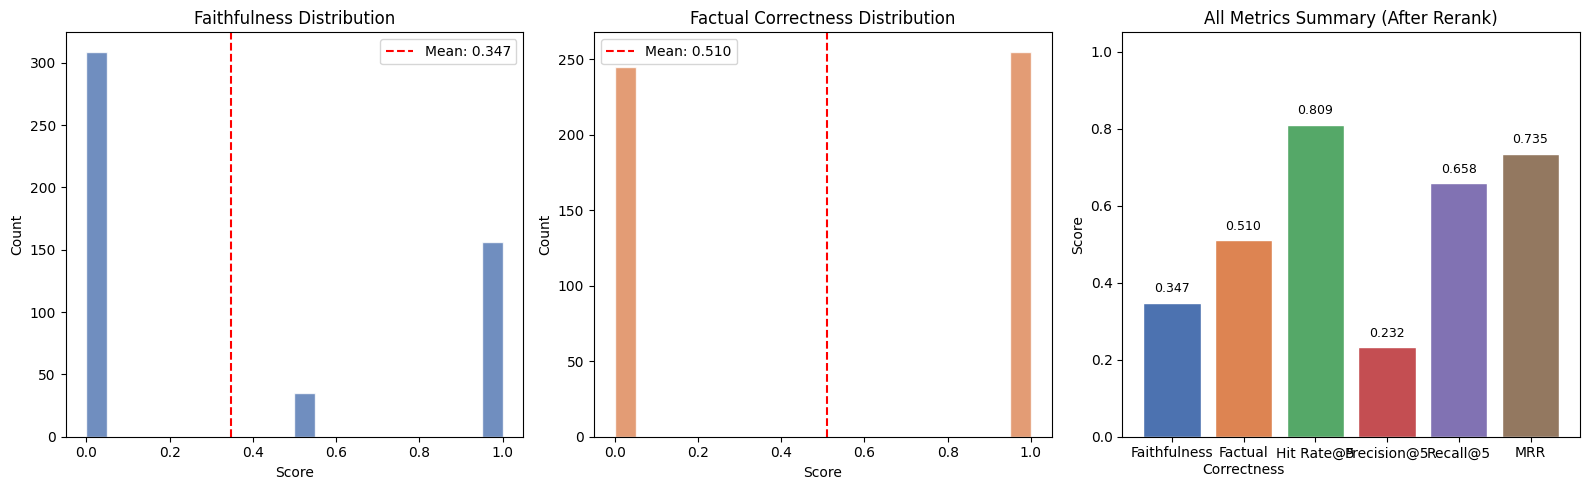

Saved figure to results/evaluation_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Distribution of Faithfulness scores
axes[0].hist(df_ragas['faithfulness'].dropna(), bins=20, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].axvline(df_ragas['faithfulness'].mean(), color="red", linestyle="--", label=f"Mean: {df_ragas['faithfulness'].mean():.3f}")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Faithfulness Distribution")
axes[0].legend()

# Plot 2: Distribution of Factual Correctness scores
axes[1].hist(df_ragas[fc_col].dropna(), bins=20, color="#DD8452", edgecolor="white", alpha=0.8)
axes[1].axvline(df_ragas[fc_col].mean(), color="red", linestyle="--", label=f"Mean: {df_ragas[fc_col].mean():.3f}")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Factual Correctness Distribution")
axes[1].legend()

# Plot 3: Summary bar chart of all metrics
all_metrics = {
    "Faithfulness": df_ragas['faithfulness'].mean(),
    "Factual\nCorrectness": df_ragas[fc_col].mean(),
    "Hit Rate@5": avg_after.get("hit_rate@5", 0),
    "Precision@5": avg_after.get("precision@5", 0),
    "Recall@5": avg_after.get("recall@5", 0),
    "MRR": avg_after.get("mrr", 0),
}

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
bars = axes[2].bar(all_metrics.keys(), all_metrics.values(), color=colors, edgecolor="white")
axes[2].set_ylabel("Score")
axes[2].set_title("All Metrics Summary (After Rerank)")
axes[2].set_ylim(0, 1.05)
for bar, val in zip(bars, all_metrics.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to results/evaluation_summary.png")

## 4.5 Final Summary

In [12]:
print("=" * 60)
print("       RAG Pipeline Evaluation Summary")
print("=" * 60)

print(f"\nDataset: PubMedQA ({len(results)} queries)")
print(f"Queries with golden docs: {queries_evaluated}")

print(f"\n--- Retrieval Metrics (After Rerank) ---")
for metric in ["hit_rate@5", "precision@5", "recall@5", "mrr"]:
    print(f"  {metric}: {avg_after.get(metric, 0):.4f}")

print(f"\n--- RAGAS Metrics (n={len(df_ragas)}) ---")
print(f"  Faithfulness: {df_ragas['faithfulness'].mean():.4f}")
print(f"  Factual Correctness: {df_ragas[fc_col].mean():.4f}")

# Accuracy
df_summary = pd.read_csv(RESULTS_DIR / "rag_summary.csv")
print(f"\n--- Answer Accuracy ---")
print(f"  Exact match: {df_summary['correct'].mean():.2%}")

print("\n" + "=" * 60)
print("All results saved to results/ directory")
print("=" * 60)

       RAG Pipeline Evaluation Summary

Dataset: PubMedQA (500 queries)
Queries with golden docs: 488

--- Retrieval Metrics (After Rerank) ---
  hit_rate@5: 0.8094
  precision@5: 0.2320
  recall@5: 0.6581
  mrr: 0.7346

--- RAGAS Metrics (n=500) ---
  Faithfulness: 0.3470
  Factual Correctness: 0.5100

--- Answer Accuracy ---
  Exact match: 51.00%

All results saved to results/ directory


## Summary

This notebook evaluated the RAG pipeline across two dimensions:

**Retrieval Quality:**
- Computed Hit Rate, Precision, Recall (at k=1,3,5,10,20) and MRR for both pre- and post-reranking stages.
- Results are saved to `results/retrieval_metrics.csv` and visualized in `results/retrieval_metrics.png`.

**Answer Quality (RAGAS):**
- **Faithfulness** measures whether the generated answer is grounded in the retrieved contexts (no hallucination).
- **Factual Correctness** measures whether the generated answer aligns with the ground-truth reference.
- Per-query scores are saved to `results/ragas_results.csv`.

**Outputs produced:**
- `results/retrieval_metrics.csv` -- retrieval metric scores before/after rerank
- `results/ragas_results.csv` -- per-query RAGAS scores
- `results/retrieval_metrics.png` -- retrieval metrics visualization
- `results/evaluation_summary.png` -- combined evaluation summary chart